# Correlation Matrix calcuation method 2:

This is the second method. Using the formulas from Lucy's paper but motified so that they were convex, the main difference now being we are calcuating the entire U matrix (now called K throughout this notebook).

To be convex, at each step of the iteration the K matrix is projected down to (hopefully) line on the intersect of two subspaces. Those being having a diagonial of ones, and being Positive semi definite.

In [13]:
from tara_preprocessing import get_just_ecog_data,get_electrode_normalized_loc,car
from noah_production_funcs import single_patient_prediction_pure,create_lapaican_rbf,create_lapaican_knn,u_metric_display
from tara_preprocessing import remove_duplicates, hold_out, preprocessing,apply_car_function,clip_time_series
from tara_preprocessing import make_patient_correlation_matrix
from noah_production_funcs import create_k
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import torch
from tqdm import tqdm

### Loading in the data

For a run down of what all the preprocessing steps do, refer to the main README document for more.

In [12]:
data_root = Path("/Users/noahwanless/Desktop/Spring2026/M467/faces_basic/data")
registered_dir = Path("../SuperEeg-M467-project/registered_outputs")
ecogs = get_just_ecog_data(registered_dir,data_root)
xyz = get_electrode_normalized_loc(registered_dir)
print('Downloaded data')
ecogs = clip_time_series(ecogs)
print("Time series clipped")
ecogs_no_dups,xyz_no_dups = remove_duplicates(ecogs,xyz)
print('Removed duplicate electrodes')
xyz_clea, cleane = preprocessing(ecogs_no_dups,xyz_no_dups,notch_size=.05)
print("Done Preprocessing")
cleaned_f,xyz_f,fake_pat_beginning,held_out_elcs = hold_out(xyz_clea,cleane,0,[40,41]) 
cleaned_f = apply_car_function(cleaned_f,0)
print("Done holding out electrodes")
patient_corr_mat = make_patient_correlation_matrix(xyz_f,cleaned_f)
print('Got Correlation Matrices, done!')

[PosixPath('../SuperEeg-M467-project/registered_outputs/aa_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/ap_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/ca_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/de_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/fp_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/ha_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/ja_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/jm_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/jt_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/mv_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/rn_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_output

In [14]:
K,loss = create_k(k=20,lamb=0.1,patient_corr_mat=patient_corr_mat,xyz_clean=xyz_f,training_steps=100,lr=0.01,graph='knn',K_proj_iter = 20)

Optimizing K


100%|██████████| 100/100 [00:51<00:00,  1.95it/s]


In [15]:
pred,indices = single_patient_prediction_pure(0,cleaned_f,(K))
print("These are the electrodes we are predicting.")
print("Their index in the list, is the index in the 'pred' object were the prediction for that electrode lives")
print(indices)

These are the electrodes we are predicting.
Their index in the list, is the index in the 'pred' object were the prediction for that electrode lives
[40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221, 2

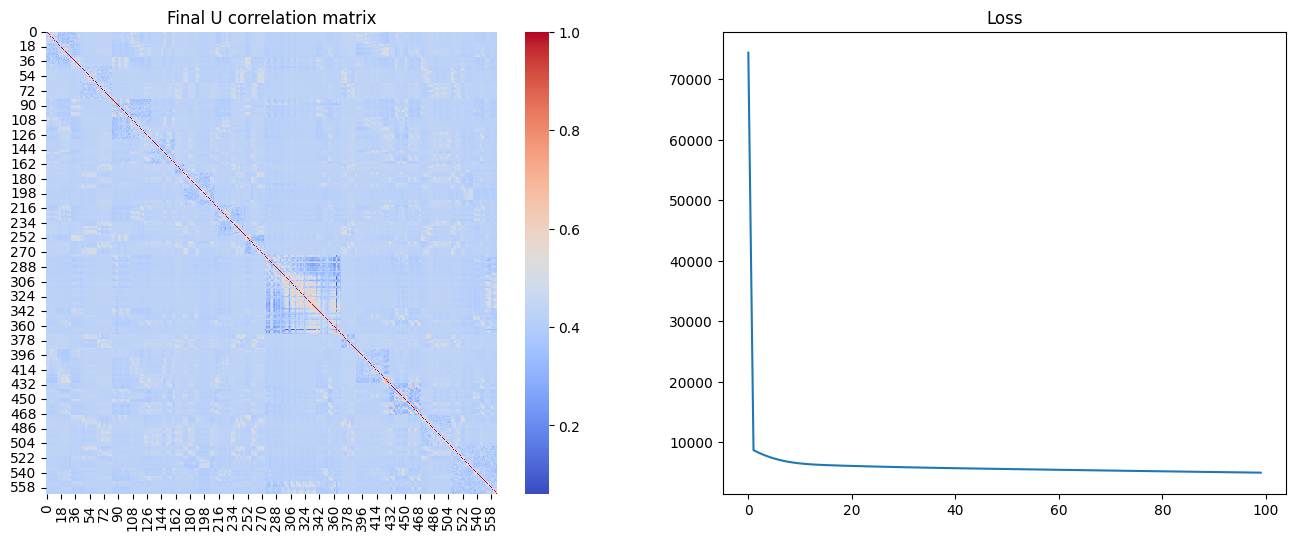

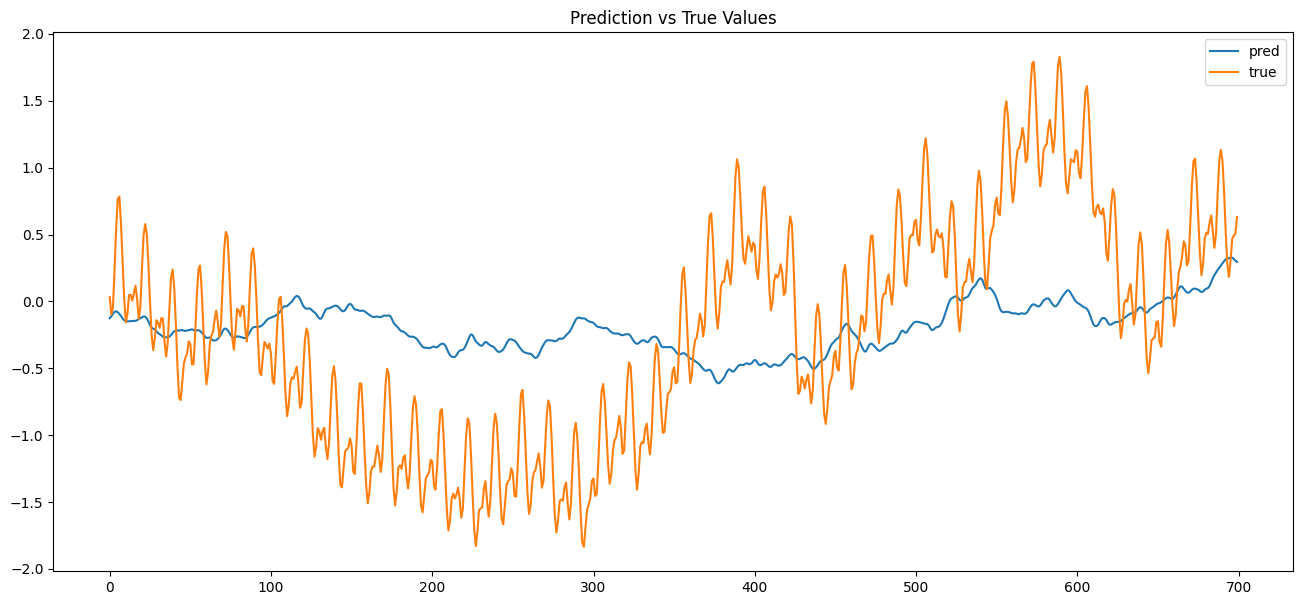

In [17]:
row_means = np.mean(held_out_elcs, axis=0, keepdims=True)
row_stds = np.std(held_out_elcs, axis=0, keepdims=True)
z_held = (held_out_elcs - row_means) / row_stds
fig, ax = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(K,ax=ax[0], cmap='coolwarm')  
ax[0].set_title('Final U correlation matrix')
ax[1].plot(loss)
ax[1].set_title('Loss')
plt.show()
    
plt.figure(figsize=(16, 7))
plt.title('Prediction vs True Values')
plt.plot(pred[9000:9700,0],label='pred')
plt.plot(z_held[9000:9700,0],label='true')
plt.legend()
plt.show()